# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [18]:
!pip install scikit-learn

In [19]:
!pip install xgboost

In [20]:
!pip install pandas

In [28]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from myutil import evaluate_skewness
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.svm import LinearSVC

ModuleNotFoundError: No module named 'myutil'

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [ ]:
# Load and view a smaple of the data
survey = pd.read_csv("data.csv")

In [ ]:
survey.head()

---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [ ]:
# Filter your data to include Q1 to Q44 and hand
survey.columns

In [ ]:
# Filter your data to include Q1 to Q44 and hand
survey = survey[['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44', 'hand']]

### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [ ]:
# Check Data Information
survey.info()

In [ ]:
# Summary Stat.
survey.describe()

In [ ]:
# Check for nulls
survey.isnull().sum()

In [ ]:
survey.head()

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> values in q1-q44 can be considered as ordinal values
> 


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

In [ ]:
# Check correlation using 'spearman'
survey.corr(method = "spearman")

In [ ]:
survey["hand"].value_counts()

__Inspect the Target__

**Quick Question:** What does each number in the target column represent?
> The values in the hand column represent the following categories:
> hand = 1 indicates the participant is right-handed
> hand = 2 indicates the participant is left-handed
> hand = 3 indicates the participant is ambidextrous
> hand = 0 likely indicates a missing value

In [23]:
# What needs to be removed from the Target?
survey = survey[survey["hand"] != 0]
survey["hand"].value_counts()

hand
1    3542
2     452
3     179
Name: count, dtype: int64

In [ ]:
# What needs to be removed from the Target?


In [24]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?
survey[survey["hand"] == 3] =2
survey.value_counts("hand")


hand
1    3542
2     631
Name: count, dtype: int64

In [25]:
survey["hand"].dtype

dtype('int64')

## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [26]:
# Identify your X and y
X = survey.drop(columns = ["hand"])
y = survey["hand"]

In [27]:
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42, stratify= y, shuffle= True)

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [30]:
from sklearn.svm import LinearSVC

In [31]:
# SVM Base Model
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

svm_base = LinearSVC()
svm_base.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [32]:
# Random Forest Base Model
rf_base = RandomForestClassifier()
rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
# XGBoost Base Model

xgboost_base = XGBClassifier()
xgboost_base.fit(X_train, y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [1 2]

__Checking the Base Models performance__

In [34]:
# SVM Base Model Result
print("SVM Train score:", svm_base.score(X_train, y_train))
print("SVM Test score:", svm_base.score(X_test, y_test))

SVM Train score: 0.8493109646494907
SVM Test score: 0.8491017964071856


In [35]:
# Random Forest Base Model Result
print("RF Train score:", rf_base.score(X_train, y_train))
print("RF Test score:", rf_base.score(X_test, y_test))

RF Train score: 1.0
RF Test score: 0.895808383233533


In [36]:
# XGBoost Model Result
print("XGBoost Train score:", xgboost_base.score(X_train, y_train))
print("XGBoost Test score:", xgboost_base.score(X_test, y_test))

NotFittedError: need to call fit or load_model beforehand

__Comparing the base model performance__

In [37]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """
    
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Display the Classification Report
    print("======================================================")
    print("                CLASSIFICATION REPORT                 ")
    print("======================================================")
    print(classification_report(y_test, y_pred, target_names = target_names, zero_division= 0.0))
    
    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels= target_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

                CLASSIFICATION REPORT                 
                      precision    recall  f1-score   support

            Right(0)       0.85      1.00      0.92       709
Left-Handed/Both (1)       0.00      0.00      0.00       126

            accuracy                           0.85       835
           macro avg       0.42      0.50      0.46       835
        weighted avg       0.72      0.85      0.78       835



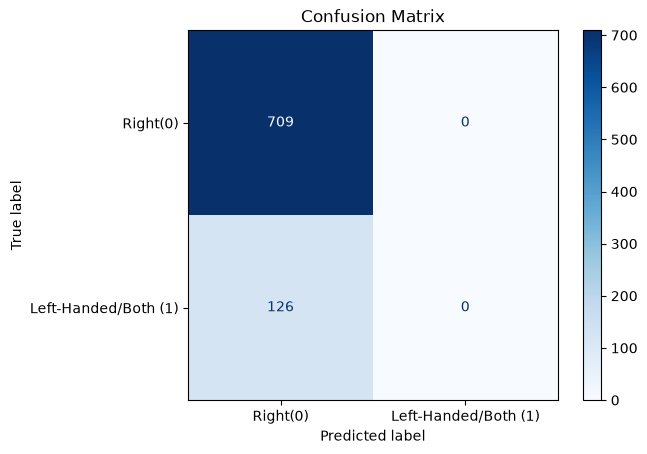

In [38]:
# SVM Base Model Performance
target_classes = ['Right(0)', 'Left-Handed/Both (1)']
evaluate_model_performance(svm_base, X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

                CLASSIFICATION REPORT                 
                      precision    recall  f1-score   support

            Right(0)       0.89      1.00      0.94       709
Left-Handed/Both (1)       1.00      0.31      0.47       126

            accuracy                           0.90       835
           macro avg       0.95      0.65      0.71       835
        weighted avg       0.91      0.90      0.87       835



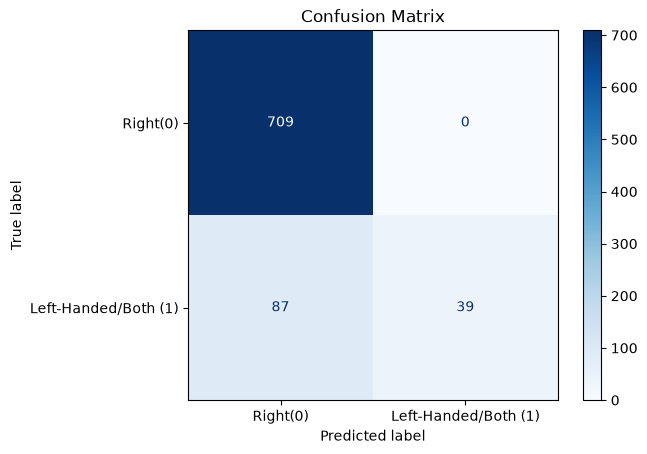

In [39]:
# Random Forest Base Model Performance
evaluate_model_performance(rf_base, X_test, y_test, target_classes)

__3. XGBoost Base Model Performance__

In [40]:
# XGBoost Base Model Performance
evaluate_model_performance(xgboost_base, X_test, y_test, target_classes)

NotFittedError: need to call fit or load_model beforehand

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [41]:
# SVM Grid Search Parameters
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [1000, 2000, 5000, 10000]
}

In [42]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30]
}
    

In [43]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6]
}

__Setting up and fitting GridSearch__

/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn

Best Parameters: {'C': 1, 'loss': 'squared_hinge', 'max_iter': 1000}
Best CV F1-Score: 0.9212405534830758
                CLASSIFICATION REPORT                 
                      precision    recall  f1-score   support

            Right(0)       0.85      1.00      0.92       709
Left-Handed/Both (1)       0.00      0.00      0.00       126

            accuracy                           0.85       835
           macro avg       0.42      0.50      0.46       835
        weighted avg       0.72      0.85      0.78       835



/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


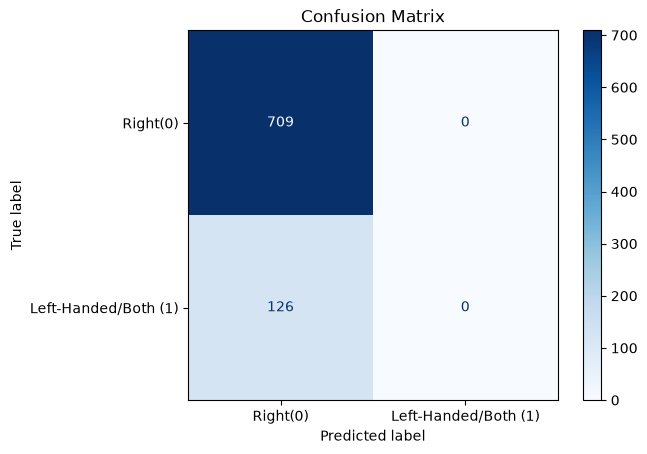

CPU times: user 263 ms, sys: 136 ms, total: 398 ms
Wall time: 5.76 s


In [44]:
%%time
# Setting up and fitting GridSearch for SVM

grid_svm = GridSearchCV(
    estimator= LinearSVC(),
    param_grid= svm_param_grid,
    cv= 5,
    scoring= "f1",
    n_jobs= -1
)

# Fit on training data
grid_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_svm.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV F1-Score: 0.9394693736125914
                CLASSIFICATION REPORT                 
                      precision    recall  f1-score   support

            Right(0)       0.89      1.00      0.94       709
Left-Handed/Both (1)       1.00      0.31      0.47       126

            accuracy                           0.90       835
           macro avg       0.95      0.65      0.71       835
        weighted avg       0.91      0.90      0.87       835



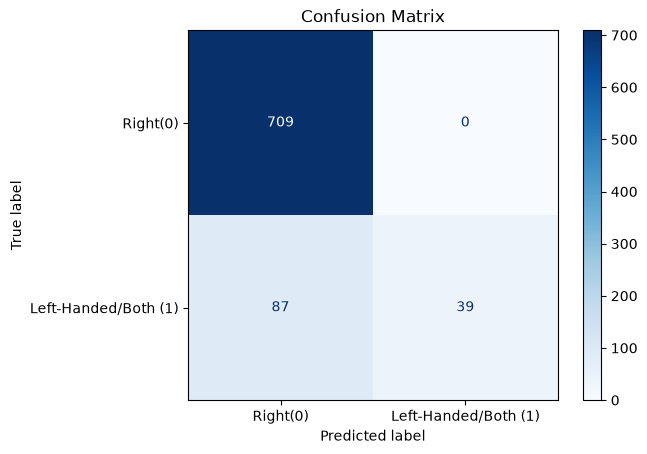

In [46]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = GridSearchCV(
    estimator= RandomForestClassifier(), 
    param_grid= rf_param_grid, 
    cv = 5, 
    scoring = "f1", 
    n_jobs = -1
)
    

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_rf.best_estimator_, X_test, y_test, target_classes)

In [47]:
%%time
# Setting up and fitting GridSearch for XGBoost
grid_xgb = GridSearchCV(
    estimator= XGBClassifier(), 
    param_grid= xgboost_param_grid, 
    cv = 5,
    scoring = "f1",
    n_jobs= -1
)

# Fit on training data
grid_xgb.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV F1-Score:", grid_xgb.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_xgb.best_estimator_, X_test, y_test, target_classes)

CPU times: user 42.4 ms, sys: 15.6 ms, total: 58.1 ms
Wall time: 271 ms


ValueError: 
All the 40 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/xgboost/core.py", line 569, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/Users/a17/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/xgboost/sklearn.py", line 1812, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [1 2]


## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here
> XGBoost performed the best with an F1 score of 0.4372, followed closely by Random Forest (0.4317), while SVM ranked last at 0.3210. Overall, all models struggled to achieve high predictive power due to highly imbalanced data and a low correlation between the survey questions and the target variable. However, XGBoost and Random Forest outperformed SVM because they are capable of capturing non-linear relationships within the dataset.


### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [ ]:
# Enter you process....


__Preprocessing__

In [ ]:
# Enter you process....


__Modeling__

In [ ]:
# Enter you process....


__Evaluating the Model__

In [ ]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!